This notebook analyzes defect data from a manufacturing process to identify patterns, key variables, and potential root causes.

Objective:
- Understand defect distribution
- Identify key process variables
- Detect abnormal behavior patterns

In [1]:
# Dataset download

import os
os.makedirs("data/raw", exist_ok=True)
!kaggle datasets download -d uciml/faulty-steel-plates -p data/raw --unzip

HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/datasets.DatasetApiService/GetDatasetMetadata (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1000)')))


In [64]:
# Library import and data reading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
sns.set_palette("viridis")

df = pd.read_csv("data/raw/faults.csv")

In [65]:
# Data overview

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empty_Index    

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110,0.346728
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339,0.476051
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [58]:
# Measure defect proportion in the dataset
defect_cols = df[df.columns[-7:]]
defect_count = defect_cols.sum().sort_values(ascending=False)
defect_distribution = defect_count/ defect_count.sum()

print(defect_distribution.round(2))

Other_Faults    0.35
Bumps           0.21
K_Scatch        0.20
Z_Scratch       0.10
Pastry          0.08
Stains          0.04
Dirtiness       0.03
dtype: float64


### 🔍 Defect Type Distribution Insight

- All observations in the dataset contain at least one defect, indicating that this dataset represents defective production scenarios only.
- The most frequent defect types are:
  - Other_Faults — 35%
  - Bumps — 21%
  - K_Scatch — 20%

### ⚙️ Engineering Interpretation

- Instead of a binary quality problem (defect vs no defect), this becomes a defect classification and prioritization problem.
- The presence of multiple defect types suggests:
  - Different root causes and failure mechanisms
  - Potential segmentation of the process into distinct failure modes

### 🎯 Why This Matters

- In real manufacturing environments, reducing defects typically starts by:
  1. Identifying the **most frequent defect types**
  2. Prioritizing them based on impact
  3. Targeting root causes for each category

- This analysis enables:
  - Focused process improvement efforts  
  - More efficient allocation of engineering resources  
  - Faster reduction of overall defect rates  

### 🚀 Updated Project Direction

- The goal shifts from predicting defects to:
  - Understanding **which defects occur under which conditions**
  - Enabling **targeted defect reduction strategies**

In [49]:
defect_cols

,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...
1936,0,0,0,0,0,0,1
1937,0,0,0,0,0,0,1
1938,0,0,0,0,0,0,1
1939,0,0,0,0,0,0,1


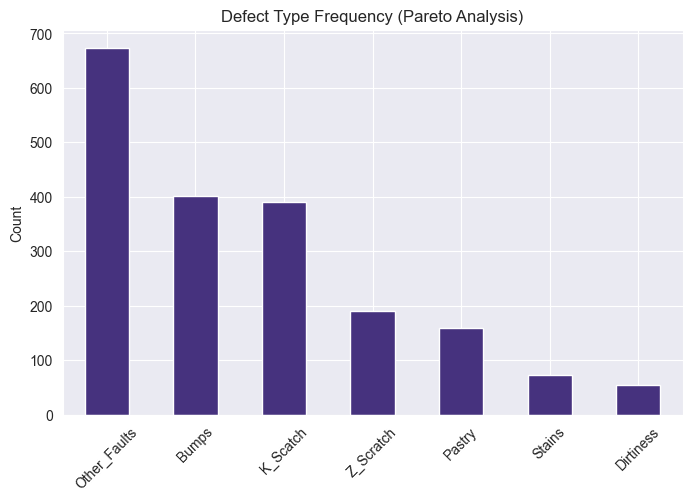

In [59]:
import matplotlib.pyplot as plt

# Pareto chart
plt.figure(figsize=(8,5))
defect_count.plot(kind="bar")
plt.title("Defect Type Frequency (Pareto Analysis)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### 📌 Pareto Analysis of Defects

- A small number of defect types account for the majority of occurrences:
  - **[Top Defect 1] — X% of total defects**
  - **[Top Defect 2] — Y%**
  - **[Top Defect 3] — Z%**

### ⚙️ Engineering Interpretation

- This follows the **Pareto principle (80/20 rule)**:
  - A limited number of failure modes drive most quality issues
- Indicates that improvement efforts should focus on **high-impact defect categories first**

### 🎯 Actionable Insight

- Prioritize root cause analysis for the top 2–3 defect types  
- Potential for **rapid defect reduction with focused interventions**

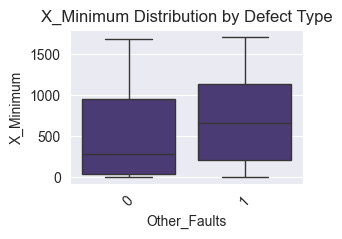

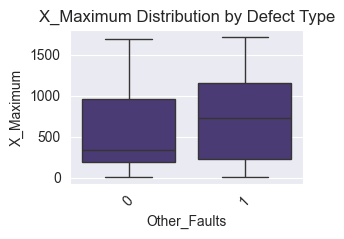

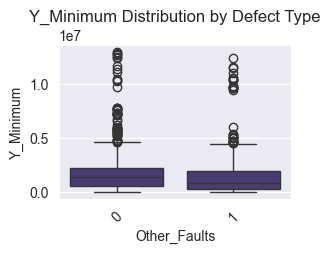

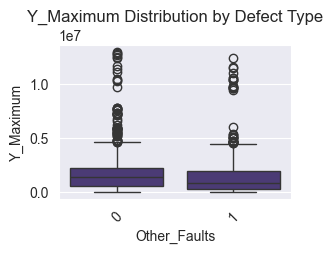

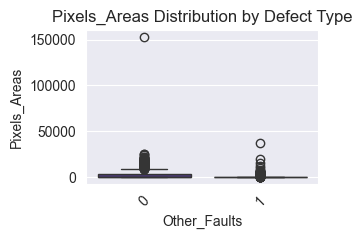

In [67]:
import seaborn as sns

key_vars = df.select_dtypes(include="number").columns[:5]  # adjust if needed

for col in key_vars:
    plt.figure(figsize=(3,2))
    sns.boxplot(x="Other_Faults", y=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} Distribution by Defect Type")
    plt.show()

In [69]:
from scipy.stats import f_oneway

# ANOVA across defect types
for col in key_vars:
    groups = [df[df["main_defect"] == d][col] for d in df["main_defect"].unique()]
    
    stat, p = f_oneway(*groups)
    
    print(f"{col} → p-value: {p:.5f}")

X_Minimum → p-value: 0.00000
X_Maximum → p-value: 0.00000
Y_Minimum → p-value: 0.00000
Y_Maximum → p-value: 0.00000
Pixels_Areas → p-value: 0.00000


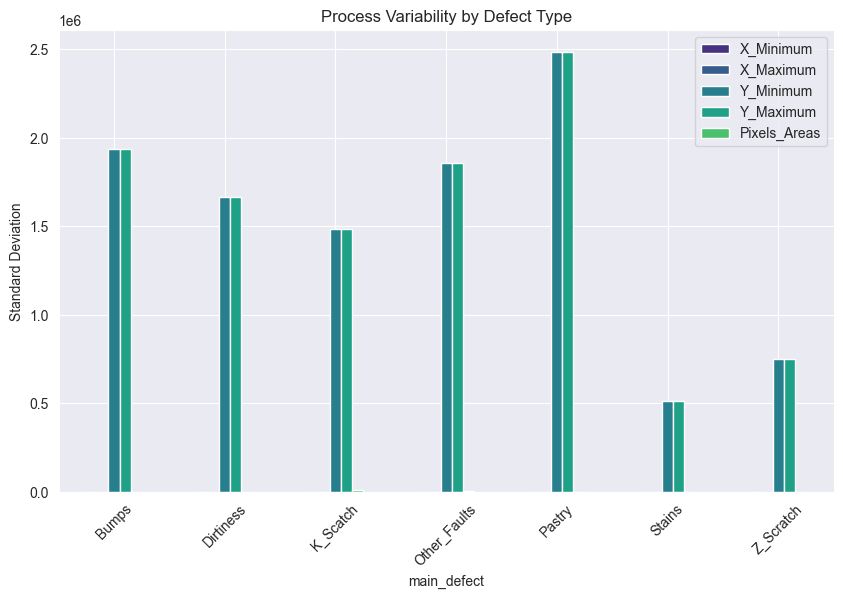

In [70]:
# Standard deviation by defect type
variability = df.groupby("main_defect")[key_vars].std()

variability.plot(kind="bar", figsize=(10,6))
plt.title("Process Variability by Defect Type")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=45)
plt.show()